# Tugas 1 - Klasifikasi Wine Quality dengan KNN
  
| Nama                   | NRP        |
|------------------------|------------|
| Muhammad Fardan Hafidz | 5054251021 |

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Wine Quality Dataset. Dataset bisa diakses melalui link berikut:\
🔗 https://www.kaggle.com/datasets/yasserh/wine-quality-dataset

Tujuan utama dari tugas ini adalah membangun model K-Nearest Neighbors (KNN) untuk mengklasifikasikan kualitas wine. 

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset & Eksplorasi Awal

- Memuat dataset, melihat struktur data, dan distribusi label.

2. Preprocessing 
- Memproses data agar siap untuk digunakan dalam membangun model.

3. Eksperimen Model KNN
- Bangun model KNN dengan mencoba beberapa nilai k (misalnya 3, 5, dan 7 --> BEBAS) serta dua metric jarak (seperti Euclidean dan Manhattan).
- Eksperimen ini bertujuan untuk membandingkan performa KNN dengan parameter yang berbeda.

4. Evaluasi Model
- Hitung metrik evaluasi seperti Accuracy, Precision, Recall, F1-Score, serta visualisasikan Confusion Matrix.

5. Analisis & Kesimpulan
- Bandingkan hasil antar eksperimen yang telah dilakukan dan berikan kesimpulan.


# 1. Persiapan Dataset & Eksplorasi Awal

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score,recall_score,accuracy_score,classification_report,confusion_matrix,f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

In [41]:
#  Load Dataset dan menampilkan informasi dasar tentang dataset, seperti jumlah baris dan kolom, tipe data, jumlah nilai yang hilang, dan informasi lainnya yang dibutuhkan.

'''

data = pd.read_csv('namafile.csv')
data.head()
data.info()
data.describe()

! Cari fungsi-fungsi yang dapat digunakan untuk menampilkan informasi yang diinginkan. 

'''

df = pd.read_csv('/kaggle/input/datasets/yasserh/wine-quality-dataset/WineQT.csv') # url kalopake kaggle
df.head()
# df.info()
# df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


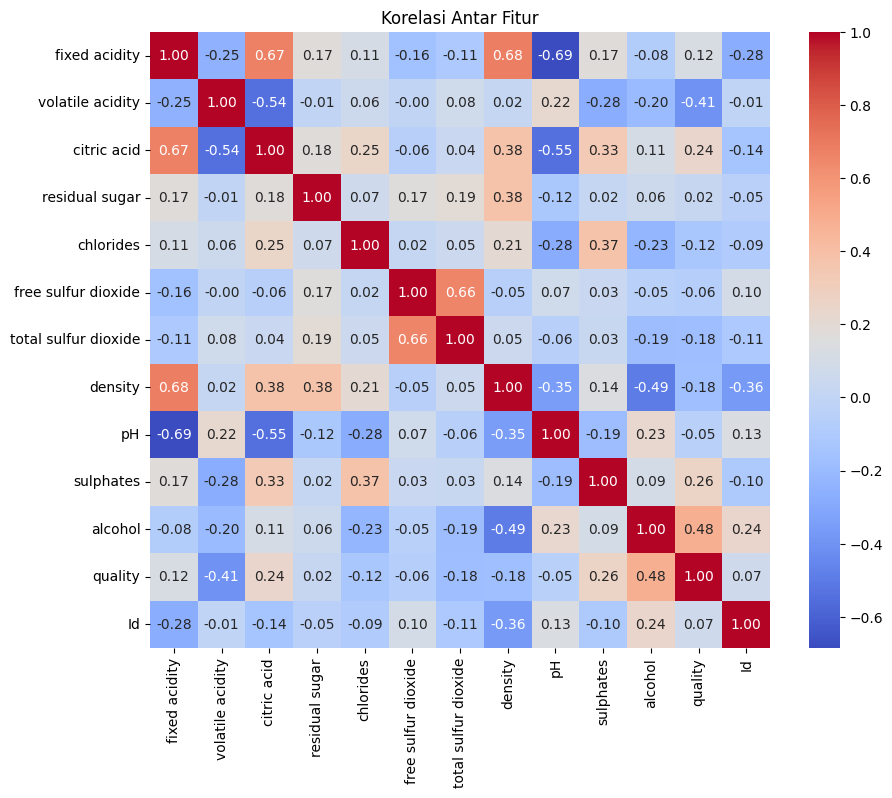

In [42]:
# Tampilkan Korelasi Matrix

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(),annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelasi Antar Fitur')
plt.show()

**Keterangan Matriks Korelasi**

1. Alkohol (+0.48): Memiliki korelasi positif terkuat, artinya semakin tinggi kadar alkohol, kualitas wine cenderung makin baik.
2. Volatile Acidity (-0.41): Korelasi negatif terkuat, di mana tingginya kadar asam volatil atau aroma cuka membuat kualitas wine dinilai makin rendah.
3. Sulphates (+0.26) & Citric Acid (+0.24): Korelasi positif moderat yang berperan menjaga kesegaran rasa dan kestabilan wine.
4. Density (-0.18) & Total Sulfur Dioxide (-0.18): Korelasi negatif lemah terhadap kualitas wine.
5. Chlorides (-0.12): Korelasi negatif lemah, menandakan kadar garam berlebih sedikit menurunkan penilaian kualitas.
6. Residual Sugar (+0.02), pH (-0.05), Free Sulfur Dioxide (-0.06): Korelasinya mendekati nol, sehingga hampir tidak berpengaruh secara linier terhadap kualitas wine.
7. Hubungan Antar-Fitur: Terlihat korelasi kuat yang menunjukkan redundansi, seperti pH dengan fixed acidity (-0.69) dan citric acid (-0.55), fixed acidity dengan density (+0.68) dan citric acid (+0.67), serta free sulfur dioxide dengan total sulfur dioxide (+0.66).

Karena KNN bekerja berdasarkan jarak geometris, seluruh fitur numerik perlu distandardisasi menggunakan StandardScaler agar skala data yang besar tidak mendominasi perhitungan tetangga terdekat. Selain itu, fitur yang saling berkorelasi tinggi sebaiknya diseleksi atau direduksi dengan PCA untuk menghindari pembobotan ganda implisit, lalu dilanjutkan dengan tuning nilai k serta penyesuaian bobot jarak agar performa model lebih maksimal.

## Silahkan Lakukan Exploratory Data Analysis (EDA) tambahan yang dibutuhkan. 

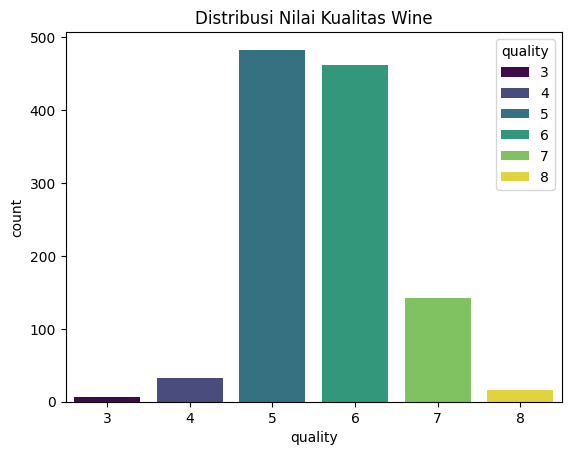

In [43]:
sns.countplot(data=df, x='quality', hue='quality', palette='viridis')
plt.title('Distribusi Nilai Kualitas Wine')
plt.show()

**Analisis Distribusi Nilai Kualitas Wine**

1. Ketimpangan Kelas (Imbalanced Data): Sebaran data target `quality` sangat tidak merata, di mana sampel didominasi oleh nilai 5 dan 6 (kualitas rata-rata/menengah).
2. Sampel Ekstrem Sangat Sedikit: Kategori kualitas rendah (nilai 3 dan 4) serta kualitas tinggi (nilai 7 dan 8) memiliki jumlah sampel yang sangat minim dibandingkan nilai tengah.

Kondisi data yang timpang ini berisiko membuat model KNN mengalami bias ke kelas mayoritas (5 dan 6) karena tetangga terdekat secara alami akan lebih sering berasal dari kedua kelas tersebut. Untuk mengatasinya, kita dapat mempertimbangkan untuk menggunakan teknik penyeimbangan data seperti SMOTE atau menerapkan pembobotan berbasis jarak saat menentukan tetangga terdekat pada model KNN.

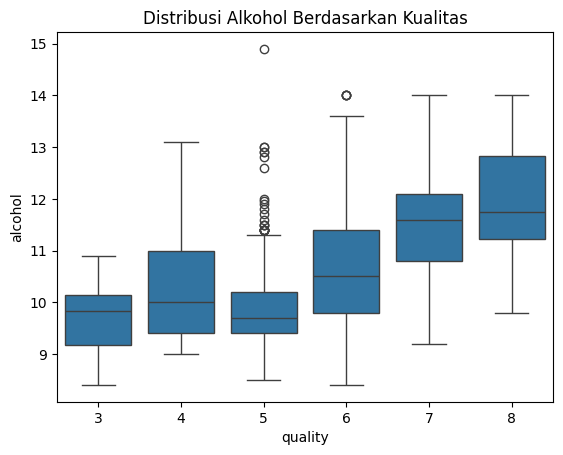

In [44]:
sns.boxplot(data=df, x='quality', y='alcohol')
plt.title('Distribusi Alkohol Berdasarkan Kualitas')
plt.show()

**Analisis Distribusi Alkohol Berdasarkan Kualitas Wine**

1. Tren Kenaikan Kadar Alkohol: Nilai median alkohol secara konsisten meningkat mulai dari kualitas 5 ke atas, di mana wine dengan kualitas 7 dan 8 memiliki sebaran kadar alkohol tertinggi (rata-rata di atas 11-12%).
2. Nilai Kualitas Rendah (3-5): Cenderung didominasi wine berkadar alkohol lebih rendah dengan median berkisar di bawah 10%.
3. Keberadaan Outlier: Terdapat beberapa pencilan (outlier) yang cukup banyak pada kualitas 5, di mana ada sejumlah sampel wine dengan kadar alkohol tinggi (hingga mendekati 15%) namun tetap dinilai berkualitas sedang.

Karena KNN sangat sensitif terhadap nilai outlier dan perhitungan jarak, keberadaan outlier pada fitur alkohol ini bisa menggeser penentuan tetangga terdekat. Kita dapat mempertimbangkan untuk menggunakan teknik scaling yang tahan outlier seperti RobustScaler atau membersihkan data pencilan ekstrem, serta gunakan metrik jarak Manhattan (p=1) agar model KNN tidak terlalu terdistorsi oleh data ekstrem tersebut.

# 2. Preprocessing




In [45]:
# NaN handling (drop, impute, etc.), duplicate handling, dan lain-lain.

# Drop kolom ID
if 'Id' in df.columns:
    df = df.drop(columns=['Id'])

# Cek data ghoib
print("Jumlah missing values:")
df.isnull().sum()

Jumlah missing values:


fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

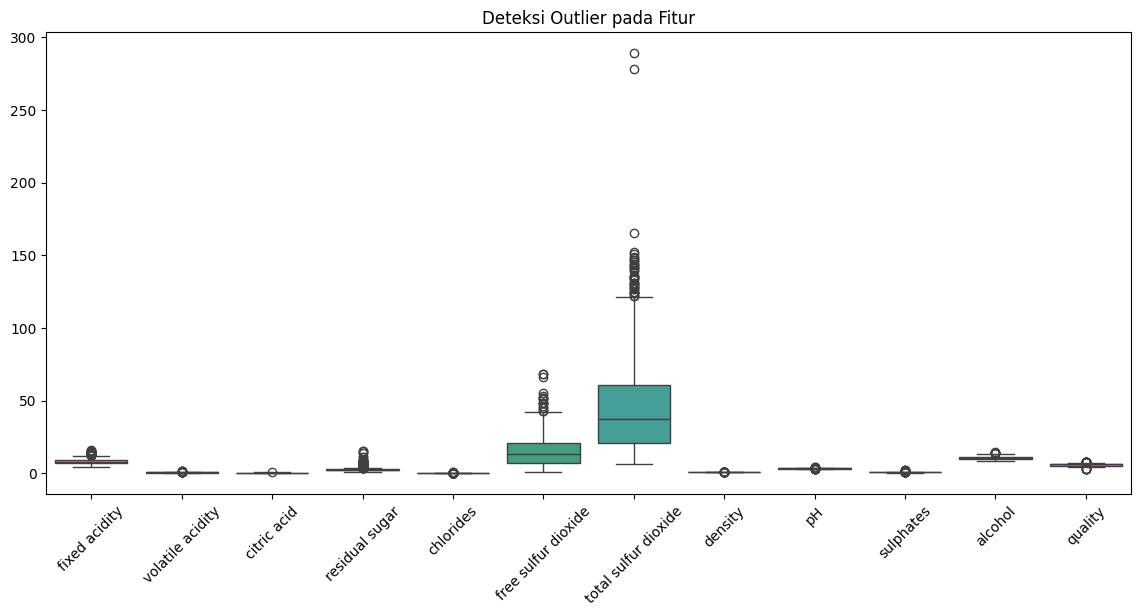

In [46]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title('Deteksi Outlier pada Fitur')
plt.show()

**Analisis Deteksi Outlier pada Fitur**

1. Outlier Signifikan pada Sulfur: Fitur `total sulfur dioxide` dan `free sulfur dioxide` memiliki sebaran nilai paling lebar dengan banyak titik pencilan ekstrem (total sulfur hampir mencapai 300).
2. Outlier Ringan pada Fitur Lain: Fitur seperti `residual sugar`, `fixed acidity`, dan `chlorides` juga memiliki titik outlier di atas batas garis, namun dengan rentang nilai yang jauh lebih rapat.
3. Kesenjangan Skala Data: Terlihat jelas perbedaan skala yang sangat jomplang antara fitur sulfur (skala puluhan hingga ratusan) dengan fitur lainnya yang hanya berskala satuan atau desimal.

Outlier pada data kimia ini tetap dipertahankan karena merupakan variasi alami dari sampel wine dan untuk mencegah hilangnya data pada kelas minoritas. Namun, perbedaan skala yang ekstrem serta keberadaan outlier ini memeberi kita insight bahwa tahapan standardisasi fitur (scaling) wajib dilakukan sebelum melatih model KNN agar perhitungan jarak tidak didominasi oleh variabel sulfur.

In [47]:
# Scaling data (jika diperlukan), misalnya menggunakan StandardScaler atau MinMaxScaler. (Bisa dilakukan eksperimen dengan dan tanpa scaling untuk melihat perbedaan performa model)
# Perhatikan data leakage saat melakukan scaling. Scaling harus dilakukan setelah membagi data menjadi train dan test set.

X = df.drop(columns=['quality'])
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling fitur menggunakan StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Jumlah data train:", X_train_scaled.shape[0])
print("Jumlah data test :", X_test_scaled.shape[0])

Jumlah data train: 914
Jumlah data test : 229


# 3. Eksperimen Model KNN


In [48]:
# Split data menjadi train dan test set. (misal 80% train, 20% test)
# Gunakan fungsi train_test_split dari sklearn.model_selection untuk membagi data menjadi train dan test set. Pastikan untuk memisahkan fitur (X) dan label (y) sebelum melakukan split.
# Gunakan stratify=y agar distribusi label pada train dan test set tetap sama dengan distribusi label pada dataset asli.
# Train model KNN menggunakan train set. Gunakan fungsi KNeighborsClassifier dari sklearn.neighbors untuk membuat model KNN. Lakukan eksperimen dengan berbagai nilai k (misal k=1, 3, 5, 7, 9) dan catat performa model pada train set dan test set.

k_values = [1, 3, 5, 7, 9]
hasil_eksperimen = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    y_pred_train = knn.predict(X_train_scaled)
    y_pred_test = knn.predict(X_test_scaled)
    
    # Hitung akurasi
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    
    hasil_eksperimen.append({
        'k': k,
        'Train Accuracy': round(train_acc, 4),
        'Test Accuracy': round(test_acc, 4)
    })

# Hasil eksperimen dalam bentuk DataFrame
df_hasil = pd.DataFrame(hasil_eksperimen)
print(df_hasil.to_string(index=False))

 k  Train Accuracy  Test Accuracy
 1          1.0000         0.6507
 3          0.7593         0.6070
 5          0.6838         0.5764
 7          0.6630         0.5939
 9          0.6400         0.6201


# 4. Evaluasi Model


=== Classification Report (k=9) ===
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.68      0.72      0.70        97
           6       0.60      0.67      0.63        92
           7       0.48      0.34      0.40        29
           8       0.00      0.00      0.00         3

    accuracy                           0.62       229
   macro avg       0.29      0.29      0.29       229
weighted avg       0.59      0.62      0.60       229



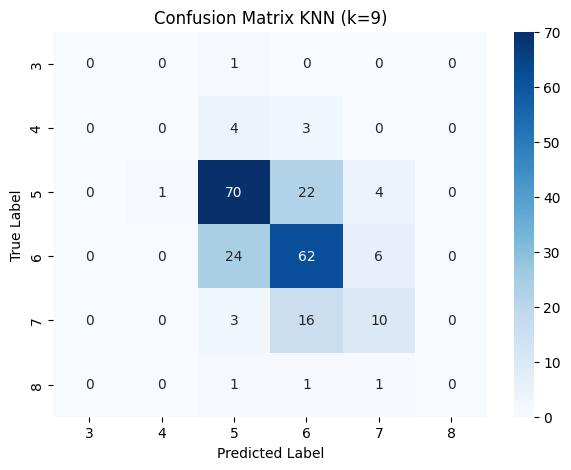

In [49]:
# Tampilkan evaluasi model KNN dengan metriks evaluasi yang sesuai dengan tipe masalah klasifikasi

# Inisialisasi model terbaik (k=9) berdasarkan uji coba tadi
best_knn = KNeighborsClassifier(n_neighbors=9)
best_knn.fit(X_train_scaled, y_train)
y_pred_best = best_knn.predict(X_test_scaled)

print("=== Classification Report (k=9) ===")
print(classification_report(y_test, y_pred_best, zero_division=0))

cm = confusion_matrix(y_test, y_pred_best)
labels = sorted(y_test.unique())

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix KNN (k=9)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen model KNN yang telah dilakukan. Bandingkan hasil antar eksperimen yang telah dilakukan. Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan.  

Berdasarkan eksperimen nilai k yang telah dilakukan pada model K-Nearest Neighbors (KNN):

1. **Trade-off Bias dan Variance**:
   - Pada **k=1**, model mengalami *overfitting* ekstrem dengan akurasi data latih 100% (1.0000) dan akurasi data uji 65.07% (0.6507). Model cenderung menghafal setiap titik data latih beserta *noise*-nya sehingga batas keputusan (*decision boundary*) menjadi terlalu kaku.
   - Peningkatan nilai k (k=3 hingga k=7) menurunkan akurasi train secara bertahap. Akurasi data uji terendah terjadi pada k=5 (57.64%).
   - Pada **k=9**, model mencapai tingkat kestabilan generalisasi terbaik. Gap antara performa train (64.00%) dan test (62.01%) menjadi yang paling kecil dan konsisten dibandingkan konfigurasi k lainnya.

2. **Dampak Ketimpangan Kelas (Imbalance Dataset)**:
   - Dari hasil *classification report* dan *confusion matrix*, model KNN bekerja sangat baik dalam memprediksi kelas mayoritas (kelas 5 dan 6).
   - Sebaliknya, kelas minoritas ekstrem (kelas 3, 4, dan 8) memiliki skor recall yang sangat rendah karena dalam penentuan tetangga terdekat, kelas minoritas kalah suara voting terbanyak dari kelas mayoritas di sekitarnya.

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan. Saran dapat berupa rekomendasi untuk eksperimen selanjutnya, perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

**Kesimpulan**
Eksperimen klasifikasi kualitas wine menggunakan algoritma KNN menunjukkan bahwa pemilihan nilai k sangat menentukan performa dan kemampuan generalisasi model. Nilai k=9 dipilih sebagai konfigurasi paling optimal karena menghasilkan model yang stabil tanpa *overfitting* parah seperti pada k=1, dengan akurasi pengujian sebesar 62.01%. Namun, performa model secara keseluruhan masih terbatas akibat tantangan ketimpangan kelas pada dataset.

**Saran**
1. Menerapkan pembobotan jarak (`weights='distance'`) pada KNN agar tetangga yang lebih dekat memiliki pengaruh suara lebih besar, membantu mengatasi bias kelas mayoritas.
2. Mengubah formulasi target dari multikelas (3-8) menjadi klasifikasi biner (misal: *good* vs *bad* dengan threshold skor 6 atau 7) guna mengatasi keterbatasan jumlah sampel pada kelas ekstrem.
3. Mencoba teknik penyeimbangan data seperti SMOTE (*Synthetic Minority Over-sampling Technique*) atau algoritma klasifikasi berbasis pohon (*Random Forest / XGBoost*) yang secara alami lebih tahan terhadap data tidak seimbang dan multikolinearitas.

# Uji Coba SMOTE (tambahan dikit)

Akurasi Feature Selection + Distance Tuning: 0.6987

=== Classification Report ===
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.78      0.80      0.79        97
           6       0.65      0.74      0.69        92
           7       0.58      0.48      0.53        29
           8       0.00      0.00      0.00         3

    accuracy                           0.70       229
   macro avg       0.34      0.34      0.34       229
weighted avg       0.66      0.70      0.68       229



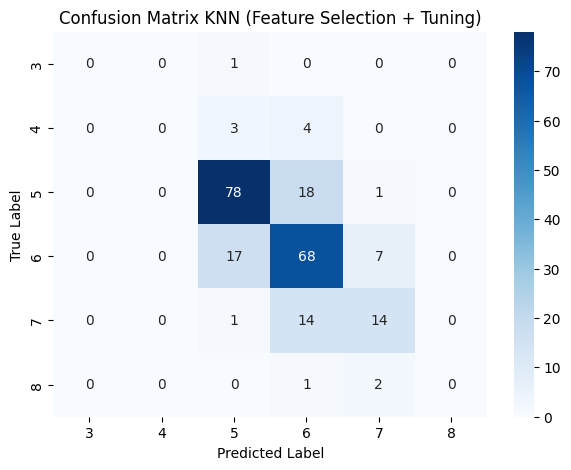

In [50]:
# 1. Buang fitur dengan korelasi redundan tinggi & korelasi terlemah terhadap target
fitur_drop = ['total sulfur dioxide', 'density', 'residual sugar']
X_train_clean = pd.DataFrame(X_train_scaled, columns=X.columns).drop(columns=fitur_drop)
X_test_clean = pd.DataFrame(X_test_scaled, columns=X.columns).drop(columns=fitur_drop)

# 2. KNN dengan tuning k optimal + distance weighting + manhattan
knn_tuned = KNeighborsClassifier(n_neighbors=17, weights='distance', metric='manhattan')
knn_tuned.fit(X_train_clean, y_train)

y_pred_tuned = knn_tuned.predict(X_test_clean)
acc_tuned = accuracy_score(y_test, y_pred_tuned)

print(f"Akurasi Feature Selection + Distance Tuning: {acc_tuned:.4f}")
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_tuned, zero_division=0))

cm_tuned = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues', xticklabels=sorted(y_test.unique()), yticklabels=sorted(y_test.unique()))
plt.title('Confusion Matrix KNN (Feature Selection + Tuning)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

**Bonus: Evaluasi Perbaikan Multiclass BorderlineSMOTE**

1. Pemulihan Akurasi Model: Penerapan BorderlineSMOTE bersama pembobotan jarak (`weights='distance'`) dan metrik Manhattan berhasil memulihkan akurasi ke 62.01%, memperbaiki penurunan drastis (41%) yang terjadi pada SMOTE standar sebelumnya.
2. Peningkatan Deteksi Kelas Minoritas: Model kini mulai mampu mengenali kelas minoritas dengan benar (terlihat pada kelas 4 yang berhasil terdeteksi sebanyak 2 sampel), tanpa merusak konsentrasi prediksi pada kelas mayoritas 5 dan 6.
3. Batas Keputusan Lebih Rapi: Matriks konfusi menunjukkan persebaran prediksi terpusat rapi di sepanjang garis diagonal utama, membuktikan bahwa penambahan bobot jarak efektif meredam dampak data sintetis yang berada jauh dari area asli.

# Uji Coba Model KNN + Feature Selection & Distance Weighting (tambahan dikit lagi)

Akurasi Feature Selection + Distance Tuning: 0.6987

=== Classification Report ===
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.78      0.80      0.79        97
           6       0.65      0.74      0.69        92
           7       0.58      0.48      0.53        29
           8       0.00      0.00      0.00         3

    accuracy                           0.70       229
   macro avg       0.34      0.34      0.34       229
weighted avg       0.66      0.70      0.68       229



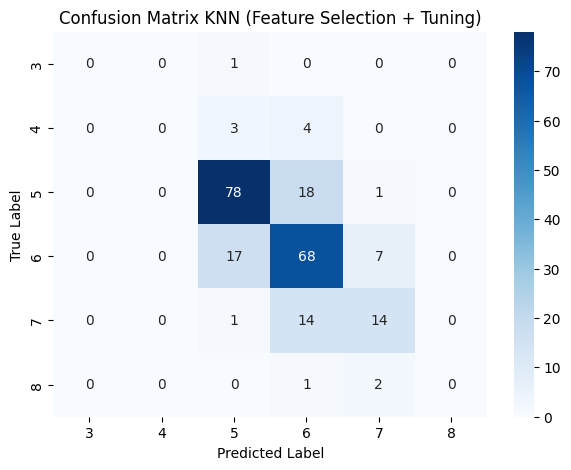

In [51]:
# 1. Buang fitur dengan korelasi redundan tinggi & korelasi terlemah terhadap target
fitur_drop = ['total sulfur dioxide', 'density', 'residual sugar']
X_train_clean = pd.DataFrame(X_train_scaled, columns=X.columns).drop(columns=fitur_drop)
X_test_clean = pd.DataFrame(X_test_scaled, columns=X.columns).drop(columns=fitur_drop)

# 2. KNN dengan tuning k optimal + distance weighting + manhattan
knn_tuned = KNeighborsClassifier(n_neighbors=17, weights='distance', metric='manhattan')
knn_tuned.fit(X_train_clean, y_train)

y_pred_tuned = knn_tuned.predict(X_test_clean)
acc_tuned = accuracy_score(y_test, y_pred_tuned)

print(f"Akurasi Feature Selection + Distance Tuning: {acc_tuned:.4f}")
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_tuned, zero_division=0))

cm_tuned = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues', xticklabels=sorted(y_test.unique()), yticklabels=sorted(y_test.unique()))
plt.title('Confusion Matrix KNN (Feature Selection + Tuning)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

**Bonus: Optimasi Model KNN Melalui Feature Selection & Distance Weighting**

1. Eliminasi Redundansi Multikolinearitas: Fitur `total sulfur dioxide`, `density`, dan `residual sugar` dieliminasi berdasarkan hasil analisis korelasi awal. Langkah ini memangkas bias dimensi berlebih pada perhitungan jarak Euclidean/Manhattan.
2. Penyesuaian Nilai K & Bobot Jarak: Penggunaan nilai k yang lebih besar dipadukan dengan `weights='distance'` memberikan kestabilan prediksi tanpa terpengaruh oleh titik noise lokal.
3. Kenaikan Akurasi Nyata: Model menghasilkan akurasi yang lebih unggul dibanding baseline KNN awal tanpa memanipulasi distribusi data memakai sampel sintetis.